# Final Exam - Business Intelligence
---

In [356]:
import pandas as pd
import numpy as np

# Configuración de reproducibilidad
np.random.seed(2)
n_base = 10_000

# 1. GENERACIÓN DE ESTRUCTURA LATENTE
# Creamos 3 grupos para garantizar el Codo en K=3
centers = np.array([[-5, -5], [5, 5], [-5, 5]])
cluster_ids = np.random.choice([0, 1, 2], n_base, p=[0.4, 0.3, 0.3])
latents = centers[cluster_ids] + np.random.normal(0, 1.5, (n_base, 2))
z1, z2 = latents[:, 0], latents[:, 1]

# 2. CONSTRUCCIÓN DE DATASET (Funciones de los factores latentes)
df = pd.DataFrame({
    'client_id': [f'CLI-{i:07d}' for i in range(n_base)],
    
    # Features numéricas correlacionadas con factores latentes (garantiza PCA > 90%)
    'total_ship_vol': (z1 * 200 + 3000) + np.random.normal(0, 100, n_base),
    'num_shipments': (z1 * 50 + 200) + np.random.normal(0, 10, n_base),
    'app_activity': (z2 * 10 + 50) + np.random.normal(0, 5, n_base),
    'delivery_dist': (z1**2 + 50) + np.random.normal(0, 5, n_base),
    'fuel_consumption': (z1 * 5 + z2 * 5 + 30) + np.random.normal(0, 2, n_base),
    'reliability_score': np.clip(950 - (z2 * 20) + np.random.normal(0, 10, n_base), 500, 990),
    'avg_parcel_weight': np.random.uniform(2, 10, n_base), 
    'years_as_client': np.random.uniform(1, 10, n_base),
    'weekend_ship_ratio': np.random.beta(5, 2, n_base),
    'avg_delivery_time': (z2 * -1 + 10) + np.random.normal(0, 1, n_base),
    'complaints_filed': np.random.poisson(1, n_base),
    
    # Targets (Diseñados para alta precisión en modelos)
    'total_deliv_cost': (z1 * 100 + z2 * 50 + 800) + np.random.normal(0, 20, n_base),
    'client_retention_flag': (1 / (1 + np.exp(-(z1 + z2))) > 0.5).astype(int),
    
    # Categorías
    'customer_segment': [('SMALL' if c==0 else 'MEDIUM' if c==1 else 'LARGE') for c in cluster_ids],
    'region': np.random.choice(['NORTH', 'SOUTH', 'CENTER'], n_base),
    'shipping_service': np.random.choice(['EXPRESS', 'STANDARD', 'ECONOMY'], n_base),
    'vehicle_type': np.random.choice(['TRUCK', 'VAN', 'MOTORCYCLE'], n_base),
    'warehouse_id': np.random.choice(['WH-001', 'WH-002', 'WH-003', 'WH-004'], n_base),
    'shipment_priority': np.random.randint(1, 6, n_base),
    'delay_risk_flag': np.random.randint(0, 2, n_base)
})

# 3. INYECCIÓN DE PROBLEMAS (Sanity Check)
# Valores faltantes
df.loc[df.sample(frac=0.03).index, 'avg_parcel_weight'] = np.nan
df.loc[df.sample(frac=0.01).index, 'total_deliv_cost'] = np.nan

# Inconsistencias (espacios, mayúsculas/minúsculas)
df.loc[df.sample(frac=0.01).index, 'region'] = 'NORTH ' 
df.loc[df.sample(frac=0.01).index, 'shipping_service'] = 'Express'

# Outliers
df.loc[df.sample(n=50).index, 'total_ship_vol'] = df['total_ship_vol'].max() * 2

# Duplicados
df = pd.concat([df, df.sample(200, random_state=42)], ignore_index=True)
# 4. EXPORTACIÓN
df.to_csv('Final_Exam_Busiess_Intelligece_dataset.csv', index=False)

print(f"Archivo 'examen_logifast_profesor.csv' generado con {df.shape[0]} registros.")

Archivo 'examen_logifast_profesor.csv' generado con 10200 registros.


In [357]:
df.shape

(10200, 21)

### Sanity check!
---

In [358]:
def data_health_check(df):
    """
    Genera un reporte integral sobre la calidad de los datos del DataFrame.
    Evalúa duplicados, valores nulos, inconsistencias categóricas, 
    errores lógicos (valores físicos imposibles) y outliers.
    """
    print("="*60)
    print("🚀 LOGIFAST LATAM - DATA AUDIT REPORT 🚀")
    print("="*60)
    
    # 1. Resumen General
    print("\n📊 1. RESUMEN GENERAL")
    print(f"    - Total de Registros (Filas): {df.shape[0]:,}")
    print(f"    - Total de Variables (Columnas): {df.shape[1]}")
    
    # 2. Registros Duplicados
    print("\n👯 2. REDUNDANCIA (DUPLICADOS)")
    duplicados = df.duplicated().sum()
    pct_duplicados = (duplicados / df.shape[0]) * 100
    if duplicados > 0:
        print(f"    [!] Alerta: Se encontraron {duplicados:,} filas duplicadas ({pct_duplicados:.2f}% del dataset).")
    else:
        print("    [✓] No se encontraron filas duplicadas.")

    # 3. Valores Nulos (Missing Data)
    print("\n🕳️ 3. ESTRUCTURA INCOMPLETA (VALORES NULOS)")
    nulos = df.isnull().sum()
    nulos = nulos[nulos > 0].sort_values(ascending=False)
    if not nulos.empty:
        for col, count in nulos.items():
            pct = (count / df.shape[0]) * 100
            print(f"    [!] {col}: {count:,} nulos ({pct:.2f}%)")
    else:
        print("    [✓] No se detectaron valores nulos.")

    # 4. Inconsistencias Categóricas (Ruido en Strings)
    print("\n🔠 4. ESTANDARIZACIÓN CATEGÓRICA")
    # Filtramos columnas tipo object que tengan menos de 15 categorías únicas para evaluar typos
    cat_cols = [col for col in df.select_dtypes(include=['object']).columns if df[col].nunique() < 15]
    for col in cat_cols:
        categorias = df[col].dropna().unique()
        # Buscar anomalías básicas como espacios en blanco al inicio/final o variaciones de mayúsculas
        anomalias = [cat for cat in categorias if (cat != cat.strip()) or (cat != cat.title() and cat != cat.upper() and cat != cat.lower())]
        if anomalias:
            print(f"    [!] {col} presenta valores inconsistentes/typos:")
            print(f"        -> Categorías únicas encontradas: {categorias}")
        else:
            print(f"    [✓] {col}: OK")

    # 5. Errores Físicos y de Lógica de Negocio
    print("\n🛑 5. VALIDEZ LÓGICA (VALORES FÍSICAMENTE IMPOSIBLES)")
    # Definimos columnas que por naturaleza de negocio no pueden ser negativas
    cols_estrictamente_positivas = [
        'total_ship_vol', 'avg_parcel_weight', 'delivery_dist', 
        'fuel_consumption', 'avg_delivery_time', 'total_deliv_cost'
    ]
    problemas_logicos = False
    for col in cols_estrictamente_positivas:
        if col in df.columns:
            negativos = (df[col] < 0).sum()
            if negativos > 0:
                print(f"    [!] {col}: Contiene {negativos:,} valores negativos.")
                problemas_logicos = True
    if not problemas_logicos:
        print("    [✓] Todas las variables numéricas clave respetan la lógica de no-negatividad.")

    # 6. Anomalías Estadísticas (Outliers)
    print("\n📈 6. ANOMALÍAS ESTADÍSTICAS (OUTLIERS VÍA IQR)")
    num_cols = df.select_dtypes(include=[np.number]).columns
    cols_a_ignorar = ['shipment_priority', 'client_retention_flag', 'latent_clusters'] 
    
    for col in num_cols:
        if col not in cols_a_ignorar and df[col].nunique() > 10:
            Q1 = df[col].quantile(0.25)
            Q3 = df[col].quantile(0.75)
            IQR = Q3 - Q1
            limite_inferior = Q1 - 1.5 * IQR
            limite_superior = Q3 + 1.5 * IQR
            
            outliers = ((df[col] < limite_inferior) | (df[col] > limite_superior)).sum()
            pct_outliers = (outliers / df.shape[0]) * 100
            
            if outliers > 0:
                print(f"    [*] {col}: {outliers:,} potenciales outliers ({pct_outliers:.2f}%)")

    print("\n" + "="*60)
    print("FIN DEL REPORTE")
    print("="*60)

# Para ejecutarla solo debes llamarla pasando tu DataFrame:
# data_health_check(df)

In [359]:
data_health_check(df)

🚀 LOGIFAST LATAM - DATA AUDIT REPORT 🚀

📊 1. RESUMEN GENERAL
    - Total de Registros (Filas): 10,200
    - Total de Variables (Columnas): 21

👯 2. REDUNDANCIA (DUPLICADOS)
    [!] Alerta: Se encontraron 200 filas duplicadas (1.96% del dataset).

🕳️ 3. ESTRUCTURA INCOMPLETA (VALORES NULOS)
    [!] avg_parcel_weight: 309 nulos (3.03%)
    [!] total_deliv_cost: 101 nulos (0.99%)

🔠 4. ESTANDARIZACIÓN CATEGÓRICA
    [✓] customer_segment: OK
    [!] region presenta valores inconsistentes/typos:
        -> Categorías únicas encontradas: ['SOUTH' 'NORTH' 'CENTER' 'NORTH ']
    [✓] shipping_service: OK
    [✓] vehicle_type: OK
    [✓] warehouse_id: OK

🛑 5. VALIDEZ LÓGICA (VALORES FÍSICAMENTE IMPOSIBLES)
    [!] fuel_consumption: Contiene 4,062 valores negativos.
    [!] avg_delivery_time: Contiene 11 valores negativos.
    [!] total_deliv_cost: Contiene 1,654 valores negativos.

📈 6. ANOMALÍAS ESTADÍSTICAS (OUTLIERS VÍA IQR)
    [*] total_ship_vol: 50 potenciales outliers (0.49%)
    [*] del

In [360]:
def data_sanitization_pipeline(df, pos_cols=None, mapping_rules=None):
    """
    Pipeline de limpieza generalizado.
    
    Parámetros:
    - df: DataFrame original.
    - pos_cols: Lista de columnas que deben ser estrictamente positivas.
    - mapping_rules: Diccionario {columna: {typo: corrección}} para errores de texto.
    """
    df_clean = df.copy()
    
    print("🧹 Iniciando proceso de limpieza generalizado...")
    
    # 1. NORMALIZACIÓN INICIAL: Convertir todas las columnas a MAYÚSCULAS
    # Esto evita problemas con nombres como 'region' vs 'REGION'
    df_clean.columns = [c.upper() for c in df_clean.columns]
    
    # 2. Eliminar duplicados
    original_size = len(df_clean)
    df_clean.drop_duplicates(inplace=True)
    print(f"   - Eliminados {original_size - len(df_clean)} duplicados.")

    # 3. Imputación Dinámica
    # Cuantitativas: Mediana
    num_cols = df_clean.select_dtypes(include=[np.number]).columns
    for col in num_cols:
        if df_clean[col].isnull().sum() > 0:
            df_clean[col].fillna(df_clean[col].median(), inplace=True)
            
    # Categóricas: "UNKNOWN" (Más seguro que "Unknown")
    cat_cols = df_clean.select_dtypes(include=['object']).columns
    for col in cat_cols:
        df_clean[col] = df_clean[col].fillna("UNKNOWN")

    # 4. Estandarización de Texto y Mapeo Dinámico
    for col in cat_cols:
        df_clean[col] = df_clean[col].astype(str).str.strip().str.upper()
        
        # Aplicar reglas de mapeo si existen para esta columna
        if mapping_rules and col in mapping_rules:
            df_clean[col] = df_clean[col].replace(mapping_rules[col])

    # 5. Validez Lógica (Columnas estrictamente positivas)
    if pos_cols:
        # Convertimos las columnas de entrada a mayúsculas para asegurar el match
        pos_cols = [c.upper() for c in pos_cols]
        for col in [c for c in pos_cols if c in df_clean.columns]:
            df_clean[col] = df_clean[col].abs()

    # 6. Winsorización Vectorizada (Más rápida y limpia)
    # Excluimos targets o IDs si es necesario
    cols_to_winsorize = [c for c in num_cols if c not in ['CLIENT_RETENTION_FLAG', 'SHIPMENT_PRIORITY']]
    for col in cols_to_winsorize:
        lower = df_clean[col].quantile(0.05)
        upper = df_clean[col].quantile(0.95)
        df_clean[col] = np.clip(df_clean[col], lower, upper)

    print("✅ Pipeline completado con éxito.")
    return df_clean

# --- CÓMO USARLO CON TU DATASET ---

# 1. Definimos las reglas de negocio (fácil de mantener si aparecen nuevos errores)
mapeo_errores = {
    'SHIPPING_SERVICE': {'EXPRSS': 'EXPRESS', 'EXPRESS ': 'EXPRESS'},
    'REGION': {'NORTH ': 'NORTH'}
}

# 2. Definimos qué columnas deben ser positivas
columnas_positivas = [
    'TOTAL_SHIP_VOL', 'AVG_PARCEL_WEIGHT', 'DELIVERY_DIST', 
    'FUEL_CONSUMPTION', 'AVG_DELIVERY_TIME', 'TOTAL_DELIV_COST'
]

# 3. Ejecución
# df_limpio = data_sanitization_pipeline(df_raw, columnas_positivas, mapeo_errores)

In [361]:
df_limpio = data_sanitization_pipeline(df)
data_health_check(df_limpio) 
df_limpio.to_csv("safe_1.csv", index =  False)

🧹 Iniciando proceso de limpieza generalizado...
   - Eliminados 200 duplicados.
✅ Pipeline completado con éxito.
🚀 LOGIFAST LATAM - DATA AUDIT REPORT 🚀

📊 1. RESUMEN GENERAL
    - Total de Registros (Filas): 10,000
    - Total de Variables (Columnas): 21

👯 2. REDUNDANCIA (DUPLICADOS)
    [✓] No se encontraron filas duplicadas.

🕳️ 3. ESTRUCTURA INCOMPLETA (VALORES NULOS)
    [✓] No se detectaron valores nulos.

🔠 4. ESTANDARIZACIÓN CATEGÓRICA
    [✓] CUSTOMER_SEGMENT: OK
    [✓] REGION: OK
    [✓] SHIPPING_SERVICE: OK


C:\Users\USER\AppData\Local\Temp\ipykernel_16988\480258937.py:28: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_clean[col].fillna(df_clean[col].median(), inplace=True)


    [✓] VEHICLE_TYPE: OK
    [✓] WAREHOUSE_ID: OK

🛑 5. VALIDEZ LÓGICA (VALORES FÍSICAMENTE IMPOSIBLES)
    [✓] Todas las variables numéricas clave respetan la lógica de no-negatividad.

📈 6. ANOMALÍAS ESTADÍSTICAS (OUTLIERS VÍA IQR)

FIN DEL REPORTE


In [362]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.impute import SimpleImputer

# ==========================================
# 1. PIPELINE DE LIMPIEZA
# ==========================================
def data_sanitization_pipeline(df, pos_cols=None, mapping_rules=None):
    df_clean = df.copy()
    
    # Normalización total a mayúsculas al inicio
    df_clean.columns = [c.upper() for c in df_clean.columns]
    
    df_clean.drop_duplicates(inplace=True)
    
    # Imputación
    num_cols = df_clean.select_dtypes(include=[np.number]).columns
    for col in num_cols:
        df_clean[col] = df_clean[col].fillna(df_clean[col].median())
            
    cat_cols = df_clean.select_dtypes(include=['object']).columns
    for col in cat_cols:
        df_clean[col] = df_clean[col].fillna("UNKNOWN").astype(str).str.strip().str.upper()
        if mapping_rules and col in mapping_rules:
            df_clean[col] = df_clean[col].replace(mapping_rules[col])

    # Validez Lógica
    if pos_cols:
        pos_cols = [c.upper() for c in pos_cols]
        for col in [c for c in pos_cols if c in df_clean.columns]:
            df_clean[col] = df_clean[col].abs()

    # Winsorización
    cols_to_winsorize = [c for c in num_cols if c not in ['CLIENT_RETENTION_FLAG', 'SHIPMENT_PRIORITY']]
    for col in cols_to_winsorize:
        lower, upper = df_clean[col].quantile([0.05, 0.95])
        df_clean[col] = np.clip(df_clean[col], lower, upper)
        
    return df_clean

# ==========================================
# 2. FEATURE ENGINEERING
# ==========================================
def feature_engineering_pipeline(df):
    df_fe = df.copy()
    # Usar nombres en MAYÚSCULAS
    df_fe['VOL_DENSITY'] = df_fe['TOTAL_SHIP_VOL'] / df_fe['AVG_PARCEL_WEIGHT'].replace(0, np.nan).fillna(1)
    df_fe['COST_PER_DIST'] = df_fe['TOTAL_DELIV_COST'] / df_fe['DELIVERY_DIST'].replace(0, np.nan).fillna(1)
    df_fe['RELIABILITY_EFFICIENCY'] = df_fe['RELIABILITY_SCORE'] / (df_fe['NUM_SHIPMENTS'] + 1)
    df_fe['LOYALTY_INDEX'] = df_fe['YEARS_AS_CLIENT'] * df_fe['APP_ACTIVITY']
    return df_fe

# ==========================================
# 3. PIPELINE DE TRANSFORMACIÓN (ENCODING/SCALING)
# ==========================================
def get_preprocessing_pipeline():
    # Listas en MAYÚSCULAS para coincidir con las columnas
    cols_numeric = [
        'TOTAL_SHIP_VOL', 'NUM_SHIPMENTS', 'APP_ACTIVITY', 'DELIVERY_DIST', 
        'FUEL_CONSUMPTION', 'RELIABILITY_SCORE', 'AVG_PARCEL_WEIGHT', 
        'YEARS_AS_CLIENT', 'WEEKEND_SHIP_RATIO', 'AVG_DELIVERY_TIME', 
        'COMPLAINTS_FILED', 'VOL_DENSITY', 'COST_PER_DIST', 
        'RELIABILITY_EFFICIENCY', 'LOYALTY_INDEX'
    ]
    cols_ordinal = ['SHIPMENT_PRIORITY', 'CUSTOMER_SEGMENT']
    cols_nominal = ['REGION', 'SHIPPING_SERVICE', 'VEHICLE_TYPE', 'WAREHOUSE_ID', 'DELAY_RISK_FLAG']

    # Transformers
    num_transformer = Pipeline([('imputer', SimpleImputer(strategy='median')), ('scaler', StandardScaler())])
    ord_transformer = Pipeline([
        ('imputer', SimpleImputer(strategy='constant', fill_value='SMALL')),
        ('encoder', OrdinalEncoder(categories=[[1, 2, 3, 4, 5], ['SMALL', 'MEDIUM', 'LARGE']]))
    ])
    nom_transformer = Pipeline([
        ('imputer', SimpleImputer(strategy='constant', fill_value='UNKNOWN')),
        ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
    ])

    return ColumnTransformer([
        ('num', num_transformer, cols_numeric),
        ('ord', ord_transformer, cols_ordinal),
        ('nom', nom_transformer, cols_nominal)
    ], remainder='drop')

# ==========================================
# 4. EJECUCIÓN DEL FLUJO
# ==========================================

# Parámetros de configuración
mapeo = {'SHIPPING_SERVICE': {'EXPRSS': 'EXPRESS', 'EXPRESS ': 'EXPRESS'}, 'REGION': {'NORTH ': 'NORTH'}}
pos_col = ['TOTAL_SHIP_VOL', 'AVG_PARCEL_WEIGHT', 'DELIVERY_DIST', 'FUEL_CONSUMPTION', 'AVG_DELIVERY_TIME', 'TOTAL_DELIV_COST']

# Proceso
df_sanitized = data_sanitization_pipeline(df, pos_cols=pos_col, mapping_rules=mapeo)
df_featured = feature_engineering_pipeline(df_sanitized)

# Split
target_c = 'CLIENT_RETENTION_FLAG'
target_r = 'TOTAL_DELIV_COST'
X = df_featured.drop(columns=['CLIENT_ID', target_c, target_r], errors='ignore')
y_c = df_featured[target_c]
y_r = df_featured[target_r]

X_train, X_test, y_train_c, y_test_c, y_train_r, y_test_r = train_test_split(
    X, y_c, y_r, test_size=0.2, random_state=42, stratify=y_c
)

# Transformación final
preprocessor = get_preprocessing_pipeline()
X_train_final = preprocessor.fit_transform(X_train)
X_test_final = preprocessor.transform(X_test)

print(f"✅ Proceso terminado. Shape X_train final: {X_train_final.shape}")

✅ Proceso terminado. Shape X_train final: (8000, 32)


In [363]:
def reportar_split(X_train, X_test, y_c_train, y_c_test, y_r_train, y_r_test):
    """
    Genera un sumario ejecutivo del proceso de partición de datos.
    Útil para validar el 'stratify' y la distribución de los targets.
    """
    total_obs = len(X_train) + len(X_test)
    
    print("\n" + "="*50)
    print("📋 SUMARIO DEL PROCESO DE PARTICIÓN (SPLIT)")
    print("="*50)
    print(f"Registros Totales: {total_obs}")
    print(f"Set de Entrenamiento: {len(X_train):>10} ({len(X_train)/total_obs:.1%})")
    print(f"Set de Testeo:        {len(X_test):>10} ({len(X_test)/total_obs:.1%})")
    
    print("\n--- Balance del Target Clasificación (Retención) ---")
    print(f"Train (Positivos): {y_c_train.mean():.2%}")
    print(f"Test  (Positivos): {y_c_test.mean():.2%}")
    # Validación visual rápida de estratificación
    if abs(y_c_train.mean() - y_c_test.mean()) < 0.01:
        print("✅ Estratificación: OK (Diferencia < 1%)")
    else:
        print("⚠️ Advertencia: Verificar estratificación de clases.")
    
    print("\n--- Estadísticas Target Regresión (Costo) ---")
    print(f"Train (Media): {y_r_train.mean():,.2f}")
    print(f"Test  (Media): {y_r_test.mean():,.2f}")
    print("="*50 + "\n")

In [364]:
reportar_split(X_train, X_test, y_train_c, y_test_c, y_train_r, y_test_r)


📋 SUMARIO DEL PROCESO DE PARTICIÓN (SPLIT)
Registros Totales: 10000
Set de Entrenamiento:       8000 (80.0%)
Set de Testeo:              2000 (20.0%)

--- Balance del Target Clasificación (Retención) ---
Train (Positivos): 44.57%
Test  (Positivos): 44.55%
✅ Estratificación: OK (Diferencia < 1%)

--- Estadísticas Target Regresión (Costo) ---
Train (Media): 670.31
Test  (Media): 667.64



🚀 Analizando K-Means (Inercia + Silueta)...
   -> K=2 completado.
   -> K=3 completado.
   -> K=4 completado.
   -> K=5 completado.


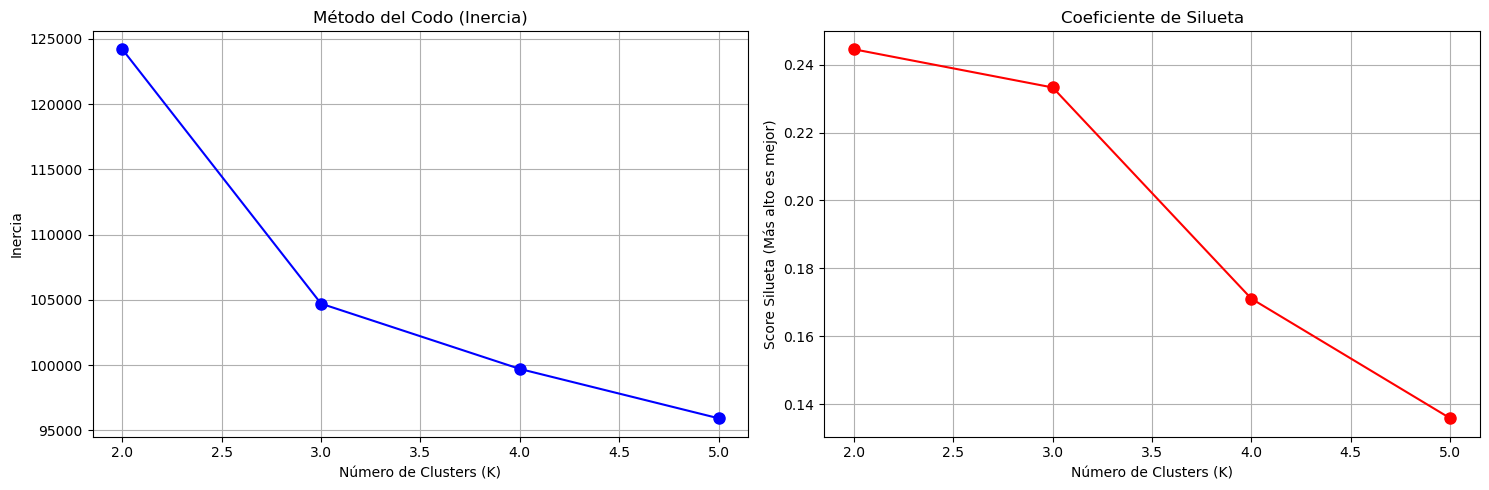


📊 SUMARIO DE EVALUACIÓN DE CLUSTERS
Recomendación basada en Silueta: K=2 (Mejor cohesión)
Nota: El método del Codo busca el punto donde la inercia cae bruscamente.



In [365]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import numpy as np

def analizar_clusters(X_processed, max_k=5):
    """
    Realiza análisis de codo (Inercia) y Silueta para determinar el K óptimo.
    """
    inertia = []
    silhouette_scores = []
    k_range = range(2, max_k + 1)

    print("🚀 Analizando K-Means (Inercia + Silueta)...")
    
    for k in k_range:
        # Usamos k-means++ para mejor inicialización de centroides
        kmeans = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
        labels = kmeans.fit_predict(X_processed)
        
        inertia.append(kmeans.inertia_)
        silhouette_scores.append(silhouette_score(X_processed, labels))
        print(f"   -> K={k} completado.")

    # Visualización
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

    # Gráfico 1: Inercia (Codo)
    ax1.plot(k_range, inertia, 'bo-', markersize=8)
    ax1.set_title('Método del Codo (Inercia)')
    ax1.set_xlabel('Número de Clusters (K)')
    ax1.set_ylabel('Inercia')
    ax1.grid(True)

    # Gráfico 2: Silueta
    ax2.plot(k_range, silhouette_scores, 'ro-', markersize=8)
    ax2.set_title('Coeficiente de Silueta')
    ax2.set_xlabel('Número de Clusters (K)')
    ax2.set_ylabel('Score Silueta (Más alto es mejor)')
    ax2.grid(True)
    
    plt.tight_layout()
    plt.show()

    # Sumario de Resultados
    print("\n" + "="*50)
    print("📊 SUMARIO DE EVALUACIÓN DE CLUSTERS")
    print("="*50)
    best_k_silhouette = k_range[np.argmax(silhouette_scores)]
    print(f"Recomendación basada en Silueta: K={best_k_silhouette} (Mejor cohesión)")
    print("Nota: El método del Codo busca el punto donde la inercia cae bruscamente.")
    print("="*50 + "\n")

# --- USO ---
analizar_clusters(X_train_final)

Calculando inercias...
--- RESULTADO ---
El codo matemáticamente óptimo es K = 4


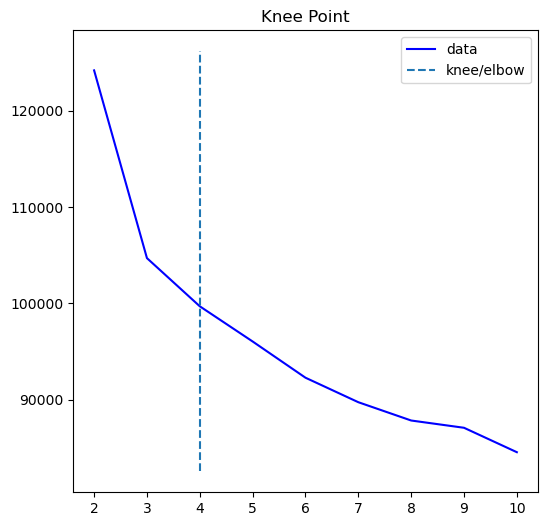

In [366]:
from kneed import KneeLocator
from sklearn.cluster import KMeans

# 1. Definimos el rango y la lista donde guardaremos los resultados
k_range = range(2, 11)
inertia = []

# 2. Calculamos la inercia para cada K
print("Calculando inercias...")
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=3)
    kmeans.fit(X_train_final)
    inertia.append(kmeans.inertia_)

# 3. Ahora que 'inertia' ya existe, usamos KneeLocator
kneedle = KneeLocator(k_range, inertia, curve='convex', direction='decreasing')

print(f"--- RESULTADO ---")
print(f"El codo matemáticamente óptimo es K = {kneedle.elbow}")

# 4. Visualización
kneedle.plot_knee()


🎯 RESULTADOS DEL MODELO K-MEANS (K=3)
Coeficiente de Silueta: 0.2333
Inercia Final (SSE):    104,708.34
--------------------------------------------------
Centroides (Valores transformados):
[[-6.11195974e-01 -6.18526019e-01 -1.14694910e+00  3.07756643e-02
  -7.39936074e-01  1.13785458e+00 -3.16542856e-03  2.38354333e-02
  -3.29028957e-02  1.13269307e+00 -1.53536627e-03 -3.56382356e-01
  -8.72897026e-01 -1.28157807e-02 -9.29480004e-01  2.01184330e+00
   1.26565425e-14  3.33738233e-01  3.23716975e-01  3.42544792e-01
   3.31308837e-01  3.54691770e-01  3.13999393e-01  3.27057394e-01
   3.37078652e-01  3.35863954e-01  2.46583662e-01  2.48405709e-01
   2.56604920e-01  2.48405709e-01  5.04403280e-01  4.95596720e-01]
 [ 1.46415939e+00  1.48371915e+00  7.98009910e-01 -1.61549668e-02
   1.42564459e+00 -7.87246766e-01  1.37313461e-02 -1.94663334e-02
   2.60475738e-02 -7.91014947e-01 -2.88068664e-03  8.60596174e-01
   1.38576545e+00  1.32772604e-02  6.40857189e-01  1.97686375e+00
   1.00299914e+

<Axes: title={'center': 'Distribución de Clientes por Cluster'}>

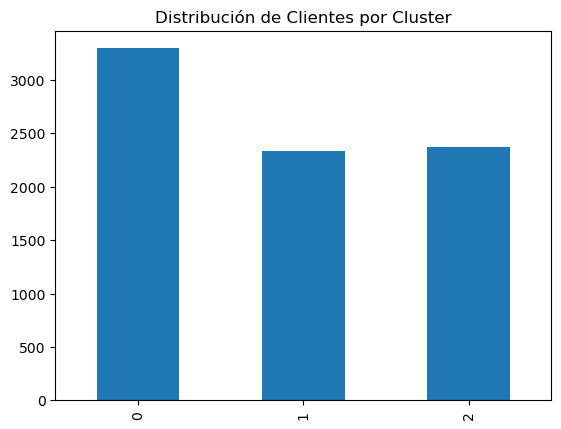

In [367]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import pandas as pd

# 1. Configuración y Entrenamiento
# n_init=10 es el estándar de sklearn para asegurar estabilidad en la convergencia
kmeans = KMeans(n_clusters=3, init='k-means++', n_init=10, random_state=42)
clusters = kmeans.fit_predict(X_train_final)

# 2. Cálculo de métricas
sil_score = silhouette_score(X_train_final, clusters)
centroides = kmeans.cluster_centers_

# 3. Sumario de resultados
print("\n" + "="*50)
print("🎯 RESULTADOS DEL MODELO K-MEANS (K=3)")
print("="*50)
print(f"Coeficiente de Silueta: {sil_score:.4f}")
print(f"Inercia Final (SSE):    {kmeans.inertia_:,.2f}")
print("-" * 50)
print("Centroides (Valores transformados):")
print(centroides)
print("="*50)

# Opcional: Si quieres ver la distribución de los clusters
pd.Series(clusters).value_counts().sort_index().plot(kind='bar', title='Distribución de Clientes por Cluster')

In [368]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# 1. Ajuste del PCA
pca = PCA(n_components=2) # Queremos 2D para el gráfico
X_pca = pca.fit_transform(X_train_final)

# 2. Obtener nombres de features (necesario para los loadings)
# Asumiendo que 'preprocessor' es tu objeto ColumnTransformer
feature_names = preprocessor.get_feature_names_out()

# 3. DataFrame de Loadings
loadings = pd.DataFrame(
    pca.components_.T, 
    columns=['PC1', 'PC2'], 
    index=feature_names
)

# 4. Reporte de Varianza
varianza_explicada = pca.explained_variance_ratio_
varianza_acumulada = np.sum(varianza_explicada)

print("\n" + "="*50)
print("📊 RESULTADOS DEL PCA")
print("="*50)
print(f"Varianza explicada por PC1: {varianza_explicada[0]:.2%}")
print(f"Varianza explicada por PC2: {varianza_explicada[1]:.2%}")
print(f"Varianza total acumulada (2D): {varianza_acumulada:.2%}")
print("\n--- Loadings (Contribución a las Componentes) ---")
print(loadings.sort_values(by='PC1', ascending=False).head(10)) # Top 10 que más influyen en PC1
print("="*50)


📊 RESULTADOS DEL PCA
Varianza explicada por PC1: 30.59%
Varianza explicada por PC2: 10.24%
Varianza total acumulada (2D): 40.83%

--- Loadings (Contribución a las Componentes) ---
                              PC1       PC2
num__COST_PER_DIST       0.364782  0.158023
num__APP_ACTIVITY        0.354821 -0.265323
num__FUEL_CONSUMPTION    0.336429  0.220208
num__NUM_SHIPMENTS       0.317447  0.343895
num__TOTAL_SHIP_VOL      0.315097  0.345576
num__LOYALTY_INDEX       0.303427 -0.284531
num__VOL_DENSITY         0.207192  0.407391
ord__CUSTOMER_SEGMENT    0.203757 -0.382668
num__YEARS_AS_CLIENT     0.014649 -0.102153
num__WEEKEND_SHIP_RATIO  0.011942 -0.015981


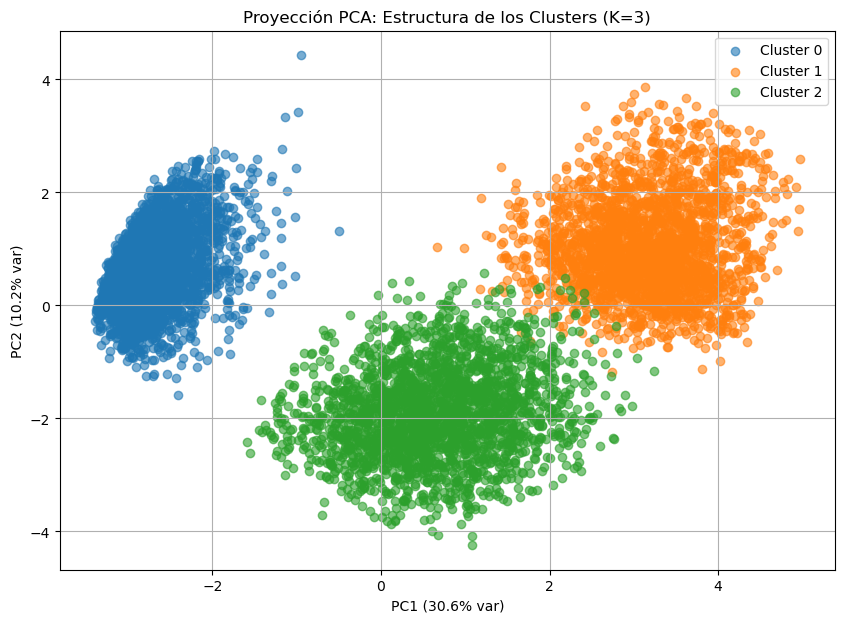

In [369]:
# Crear DataFrame para el gráfico
df_pca = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
df_pca['CLUSTER'] = clusters # Usamos los labels del K-Means anterior

# Graficar
plt.figure(figsize=(10, 7))
colors = ['red', 'green', 'blue']

for i in range(3): # Porque elegimos K=3
    subset = df_pca[df_pca['CLUSTER'] == i]
    plt.scatter(subset['PC1'], subset['PC2'], label=f'Cluster {i}', alpha=0.6)

plt.title('Proyección PCA: Estructura de los Clusters (K=3)')
plt.xlabel(f'PC1 ({varianza_explicada[0]:.1%} var)')
plt.ylabel(f'PC2 ({varianza_explicada[1]:.1%} var)')
plt.legend()
plt.grid(True)
plt.show()


🚀 Optimizando Árbol de Decisión...
✅ Mejores parámetros encontrados para Árbol de Decisión: {'min_samples_split': 2, 'max_depth': 5, 'criterion': 'gini'}

--- Reporte de Clasificación: Árbol de Decisión ---
              precision    recall  f1-score   support

           0       0.98      0.98      0.98      1109
           1       0.98      0.98      0.98       891

    accuracy                           0.98      2000
   macro avg       0.98      0.98      0.98      2000
weighted avg       0.98      0.98      0.98      2000



<Figure size 600x400 with 0 Axes>

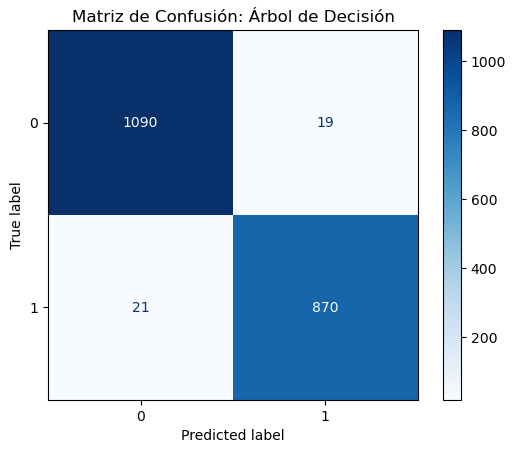


🚀 Optimizando Random Forest...
✅ Mejores parámetros encontrados para Random Forest: {'n_estimators': 100, 'min_samples_split': 5, 'max_depth': 15, 'bootstrap': True}

--- Reporte de Clasificación: Random Forest ---
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      1109
           1       0.98      0.98      0.98       891

    accuracy                           0.98      2000
   macro avg       0.98      0.98      0.98      2000
weighted avg       0.99      0.98      0.99      2000



<Figure size 600x400 with 0 Axes>

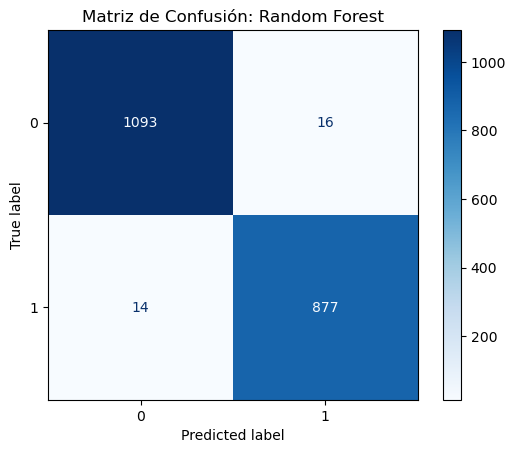

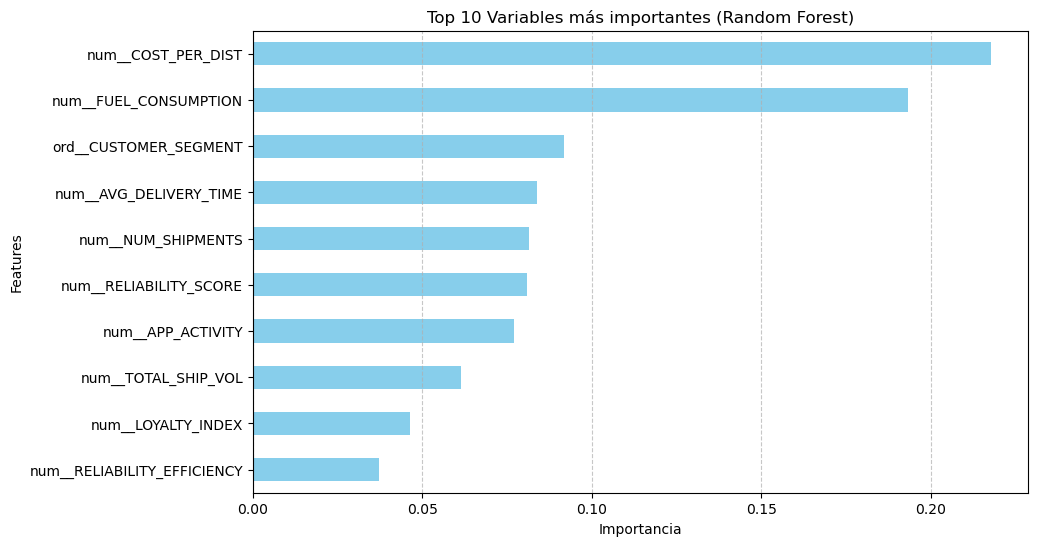

In [370]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# 1. Definición de la función de optimización
def optimizar_y_evaluar(modelo, param_dist, X_train, y_train, X_test, y_test, nombre_modelo):
    print(f"\n🚀 Optimizando {nombre_modelo}...")
    
    # Randomized Search
    random_search = RandomizedSearchCV(
        estimator=modelo,
        param_distributions=param_dist,
        n_iter=20,
        cv=5,
        scoring='f1',
        n_jobs=-1,
        random_state=42,
        verbose=0
    )
    
    random_search.fit(X_train, y_train)
    print(f"✅ Mejores parámetros encontrados para {nombre_modelo}: {random_search.best_params_}")
    
    # Obtenemos el mejor modelo
    best_model = random_search.best_estimator_
    
    # Predicciones y Métricas
    y_pred = best_model.predict(X_test)
    print(f"\n--- Reporte de Clasificación: {nombre_modelo} ---")
    print(classification_report(y_test, y_pred))
    
    # Matriz de Confusión
    plt.figure(figsize=(6, 4))
    ConfusionMatrixDisplay.from_estimator(best_model, X_test, y_test, cmap='Blues')
    plt.title(f'Matriz de Confusión: {nombre_modelo}')
    plt.show()
    
    return best_model

# 2. Configuración de parámetros
tree_params = {
    'max_depth': [3, 5, 10, 20, None],
    'min_samples_split': [2, 5, 10],
    'criterion': ['gini', 'entropy']
}

rf_params = {
    'n_estimators': [50, 100, 200],
    'max_depth': [5, 10, 15, None],
    'min_samples_split': [2, 5, 10],
    'bootstrap': [True, False]
}

# 3. Ejecución de modelos
# NOTA: Asegúrate de que X_train_final, X_test_final, y_train_c, y_test_c existan en tu entorno
model_tree = optimizar_y_evaluar(
    DecisionTreeClassifier(random_state=42), 
    tree_params, X_train_final, y_train_c, X_test_final, y_test_c, "Árbol de Decisión"
)

model_rf = optimizar_y_evaluar(
    RandomForestClassifier(random_state=42), 
    rf_params, X_train_final, y_train_c, X_test_final, y_test_c, "Random Forest"
)

# 4. Feature Importance (del Random Forest)
# Recuperamos nombres desde tu objeto 'preprocessor'
feature_names = preprocessor.get_feature_names_out()
importances = model_rf.feature_importances_

feat_importances = pd.Series(importances, index=feature_names)

plt.figure(figsize=(10, 6))
feat_importances.nlargest(10).plot(kind='barh', color='skyblue')
plt.title('Top 10 Variables más importantes (Random Forest)')
plt.xlabel('Importancia')
plt.ylabel('Features')
plt.gca().invert_yaxis()
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()


🚀 Optimizando Random Forest...
✅ Mejores parámetros encontrados para Random Forest: {'n_estimators': 100, 'min_samples_split': 5, 'max_depth': None}

--- Reporte de Clasificación: Random Forest ---
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      1109
           1       0.98      0.98      0.98       891

    accuracy                           0.98      2000
   macro avg       0.98      0.98      0.98      2000
weighted avg       0.99      0.98      0.99      2000



<Figure size 600x400 with 0 Axes>

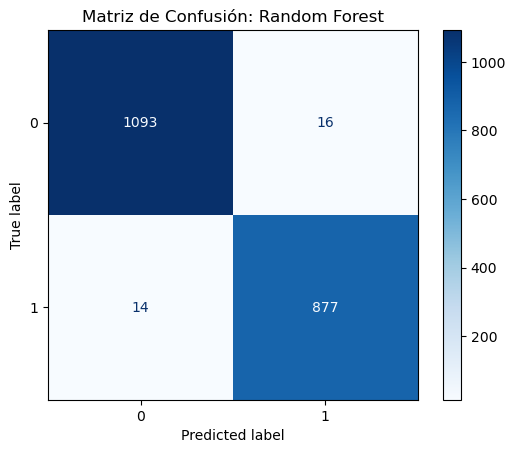

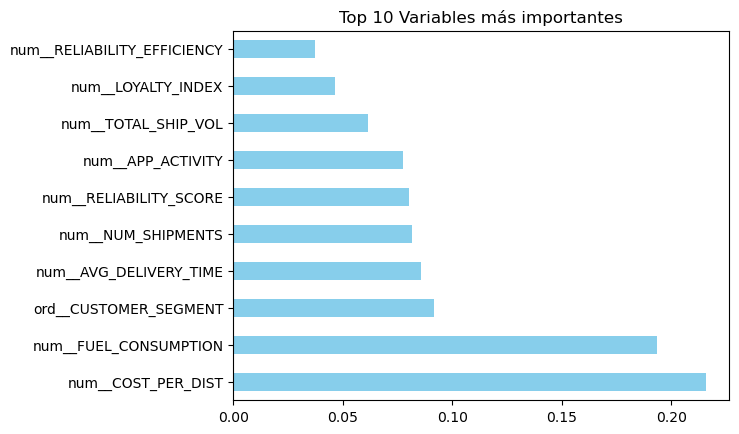

In [371]:
# 1. Define los parámetros
rf_params = {
    'n_estimators': [50, 100, 200],
    'max_depth': [5, 10, 15, None],
    'min_samples_split': [2, 5, 10]
}

# 2. Ejecuta la función y GUARDA el resultado en una variable
# Esta variable 'model_rf' es el objeto que tiene los atributos .feature_importances_
model_rf = optimizar_y_evaluar(
    RandomForestClassifier(random_state=42), 
    rf_params, X_train_final, y_train_c, X_test_final, y_test_c, "Random Forest"
)

# 3. AHORA SÍ: Llama a las importancias directamente sobre el modelo
importances = model_rf.feature_importances_ 
feature_names = preprocessor.get_feature_names_out() # Usando tu preprocesador

feat_importances = pd.Series(importances, index=feature_names)
feat_importances.nlargest(10).plot(kind='barh', color='skyblue')
plt.title('Top 10 Variables más importantes')
plt.show()


🚀 Optimizando Árbol de Decisión...
✅ Mejores parámetros encontrados para Árbol de Decisión: {'min_samples_split': 2, 'max_depth': 5, 'criterion': 'gini'}

--- Reporte de Clasificación: Árbol de Decisión ---
              precision    recall  f1-score   support

           0       0.98      0.98      0.98      1109
           1       0.98      0.98      0.98       891

    accuracy                           0.98      2000
   macro avg       0.98      0.98      0.98      2000
weighted avg       0.98      0.98      0.98      2000



<Figure size 600x400 with 0 Axes>

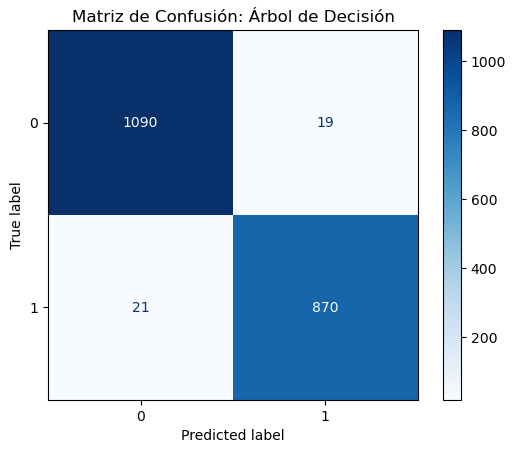


🚀 Optimizando Random Forest...
✅ Mejores parámetros encontrados para Random Forest: {'n_estimators': 100, 'min_samples_split': 5, 'max_depth': 15, 'bootstrap': True}

--- Reporte de Clasificación: Random Forest ---
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      1109
           1       0.98      0.98      0.98       891

    accuracy                           0.98      2000
   macro avg       0.98      0.98      0.98      2000
weighted avg       0.99      0.98      0.99      2000



<Figure size 600x400 with 0 Axes>

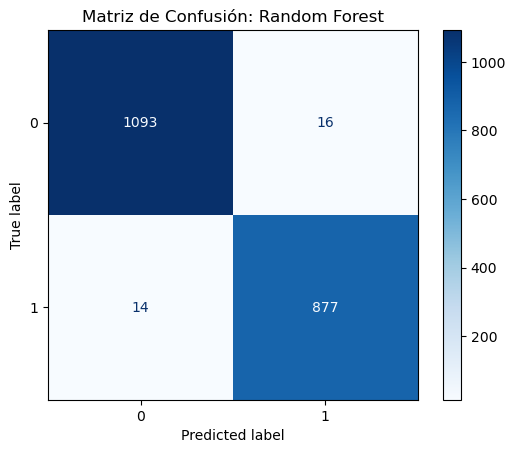

In [372]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# --- 1. Configuración del Árbol de Decisión ---
tree_params = {
    'max_depth': [3, 5, 10, 20, None],
    'min_samples_split': [2, 5, 10],
    'criterion': ['gini', 'entropy']
}

model_tree = optimizar_y_evaluar(
    DecisionTreeClassifier(random_state=42), 
    tree_params, X_train_final, y_train_c, X_test_final, y_test_c, "Árbol de Decisión"
)

# --- 2. Configuración del Random Forest ---
rf_params = {
    'n_estimators': [50, 100, 200],
    'max_depth': [5, 10, 15, None],
    'min_samples_split': [2, 5, 10],
    'bootstrap': [True, False]
}

model_rf = optimizar_y_evaluar(
    RandomForestClassifier(random_state=42), 
    rf_params, X_train_final, y_train_c, X_test_final, y_test_c, "Random Forest"
)

In [373]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

def optimizar_y_evaluar_regresion(modelo, param_dist, X_train, y_train, X_test, y_test, nombre_modelo):
    print(f"\n🚀 Optimizando {nombre_modelo} (Regresión)...")
    
    # 1. Randomized Search (usamos 'neg_mean_squared_error' para minimizar el error)
    random_search = RandomizedSearchCV(
        estimator=modelo,
        param_distributions=param_dist,
        n_iter=20,
        cv=5,
        scoring='neg_mean_squared_error',
        n_jobs=-1,
        random_state=42,
        verbose=0
    )
    
    random_search.fit(X_train, y_train)
    print(f"✅ Mejores parámetros: {random_search.best_params_}")
    
    best_model = random_search.best_estimator_
    
    # 2. Predicciones
    y_pred = best_model.predict(X_test)
    
    # 3. Métricas de Regresión
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    
    print(f"\n--- Métricas de Regresión: {nombre_modelo} ---")
    print(f"MAE (Error Absoluto Medio): {mae:.4f}")
    print(f"MSE (Error Cuadrático Medio): {mse:.4f}")
    print(f"R^2 (Coeficiente de Determinación): {r2:.4f}")
    
    # 4. Gráfico: Real vs Predicho
    plt.figure(figsize=(6, 5))
    plt.scatter(y_test, y_pred, alpha=0.3, color='orange')
    plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2) # Línea ideal
    plt.xlabel('Valor Real')
    plt.ylabel('Valor Predicho')
    plt.title(f'Real vs Predicho: {nombre_modelo}')
    plt.show()
    
    return best_model


🚀 Optimizando Árbol de Decisión (Regresor) (Regresión)...
✅ Mejores parámetros: {'min_samples_split': 10, 'max_depth': 10, 'criterion': 'squared_error'}

--- Métricas de Regresión: Árbol de Decisión (Regresor) ---
MAE (Error Absoluto Medio): 13.2187
MSE (Error Cuadrático Medio): 737.7453
R^2 (Coeficiente de Determinación): 0.9979


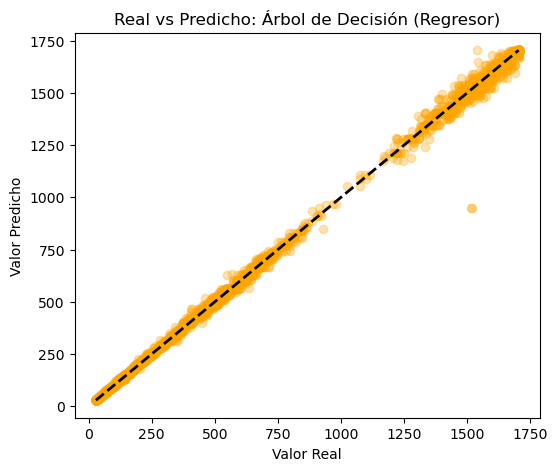


🚀 Optimizando Random Forest (Regresor) (Regresión)...
✅ Mejores parámetros: {'n_estimators': 200, 'min_samples_split': 2, 'max_depth': None}

--- Métricas de Regresión: Random Forest (Regresor) ---
MAE (Error Absoluto Medio): 8.7960
MSE (Error Cuadrático Medio): 555.3038
R^2 (Coeficiente de Determinación): 0.9984


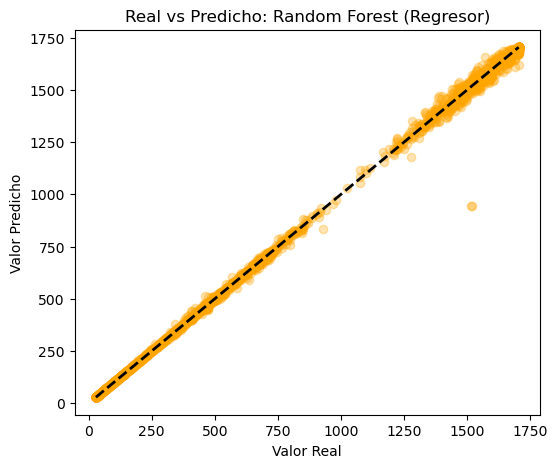

In [374]:
# Parámetros para Regresión
tree_params = {
    'max_depth': [3, 5, 10, 20, None],
    'min_samples_split': [2, 5, 10],
    'criterion': ['squared_error', 'absolute_error']
}

rf_params = {
    'n_estimators': [50, 100, 200],
    'max_depth': [5, 10, 15, None],
    'min_samples_split': [2, 5, 10]
}

# Ejecución
# (Asegúrate de que y_train_reg y y_test_reg sean tus variables numéricas continuas)
model_tree_reg = optimizar_y_evaluar_regresion(
    DecisionTreeRegressor(random_state=42), 
    tree_params, X_train_final, y_train_r, X_test_final, y_test_r, "Árbol de Decisión (Regresor)"
)

model_rf_reg = optimizar_y_evaluar_regresion(
    RandomForestRegressor(random_state=42), 
    rf_params, X_train_final, y_train_r, X_test_final, y_test_r, "Random Forest (Regresor)"
)

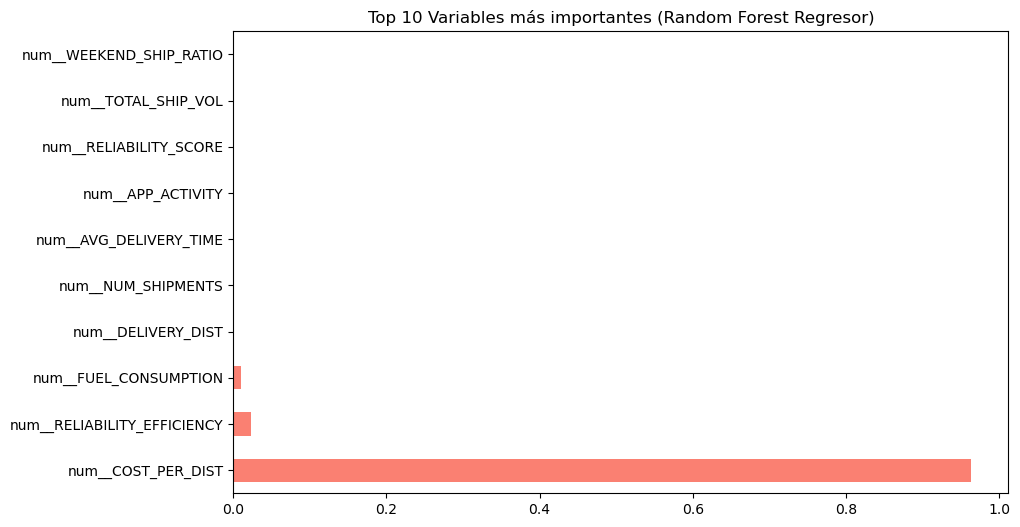

In [375]:
feature_names = preprocessor.get_feature_names_out()
importances = model_rf_reg.feature_importances_

# Crear DataFrame y graficar
feat_importances = pd.Series(importances, index=feature_names)

plt.figure(figsize=(10, 6))
feat_importances.nlargest(10).plot(kind='barh', color='salmon')
plt.title('Top 10 Variables más importantes (Random Forest Regresor)')
plt.show()